## Data Demo

In [2]:
import sys
sys.path.append('..')

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from dataset import load_traffic_data

MAT_PATH = '../data/traffic_dataset.mat'


(X_tr, Y_tr, X_te, Y_te,y_scaler, Y_train_scaled, Y_test_scaled,
 sensor_cols, n_train, n_test, n_sensors, n_feats, adj_matrix) = load_traffic_data(MAT_PATH)

print(f'Training samples : {len(Y_tr):,}  ({n_train} timesteps x {n_sensors} sensors)')
print(f'Test samples     : {len(Y_te):,}  ({n_test} timesteps x {n_sensors} sensors)')
print(f'Features per obs : {n_feats}')
print(f'X_tr shape       : {tuple(X_tr.shape)}')
print(f'Y_tr shape       : {tuple(Y_tr.shape)}')

Training samples : 45,396  (1261 timesteps x 36 sensors)
Test samples     : 30,240  (840 timesteps x 36 sensors)
Features per obs : 48
X_tr shape       : (45396, 1, 48)
Y_tr shape       : (45396,)


## 1. Traffic Volume Distribution across all Sensors 

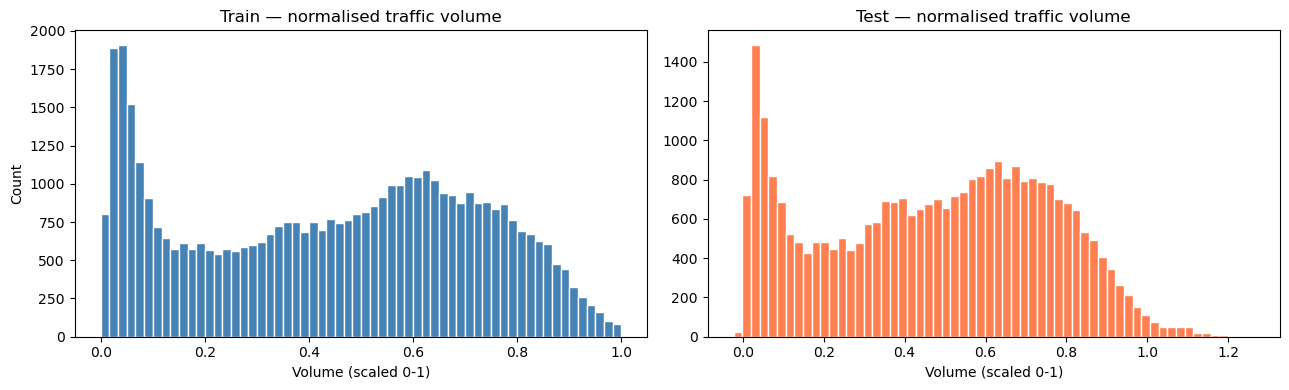

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(Y_train_scaled.flatten(), bins=60, color='steelblue', edgecolor='white')
axes[0].set_title('Train — normalised traffic volume')
axes[0].set_xlabel('Volume (scaled 0-1)')
axes[0].set_ylabel('Count')

axes[1].hist(Y_test_scaled.flatten(), bins=60, color='coral', edgecolor='white')
axes[1].set_title('Test — normalised traffic volume')
axes[1].set_xlabel('Volume (scaled 0-1)')

plt.tight_layout()
plt.show()

## Traffic Volume over time - selected sensors 

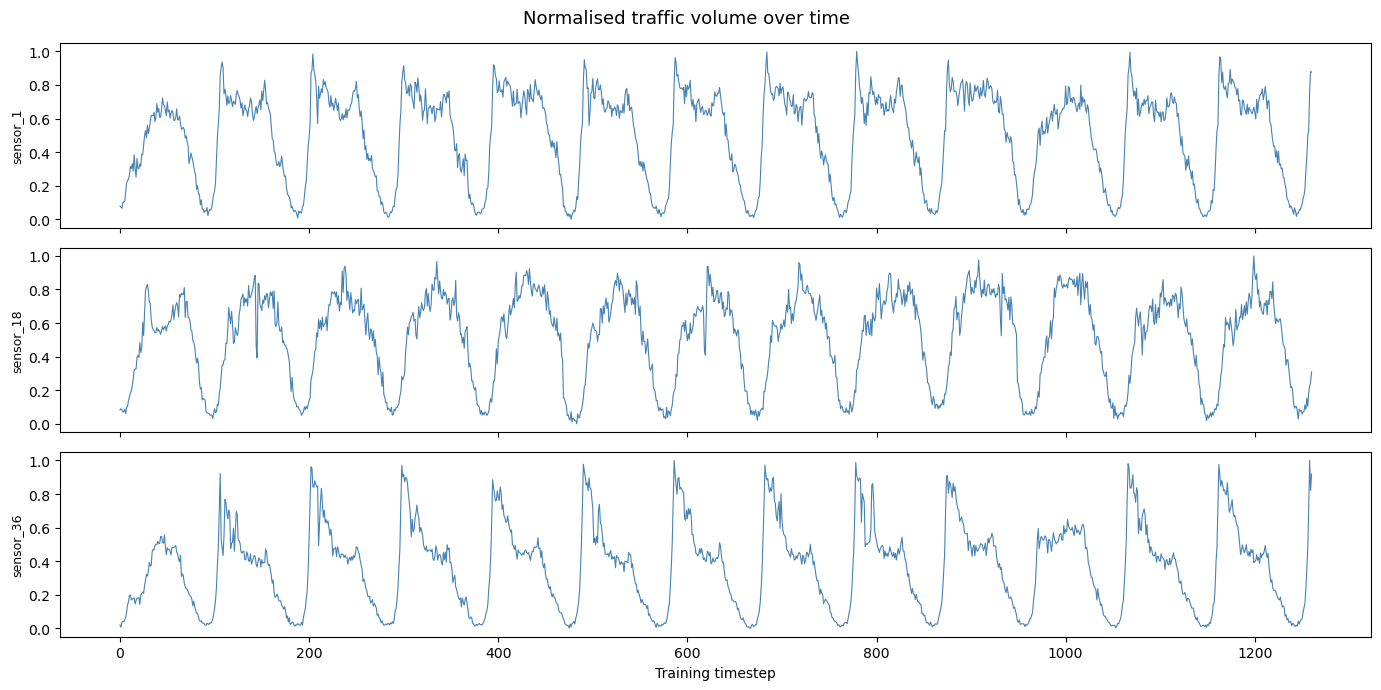

In [4]:
sensors_to_plot = [0, 17, 35]
fig, axes = plt.subplots(len(sensors_to_plot), 1, figsize=(14, 7), sharex=True)

for ax, s in zip(axes, sensors_to_plot):
    ax.plot(Y_train_scaled[:, s], linewidth=0.8, color='steelblue')
    ax.set_ylabel(sensor_cols[s], fontsize=9)

axes[-1].set_xlabel('Training timestep')
fig.suptitle('Normalised traffic volume over time', fontsize=13)
plt.tight_layout()
plt.show()

## 3. Hour-of-day pattern (from feature columns)

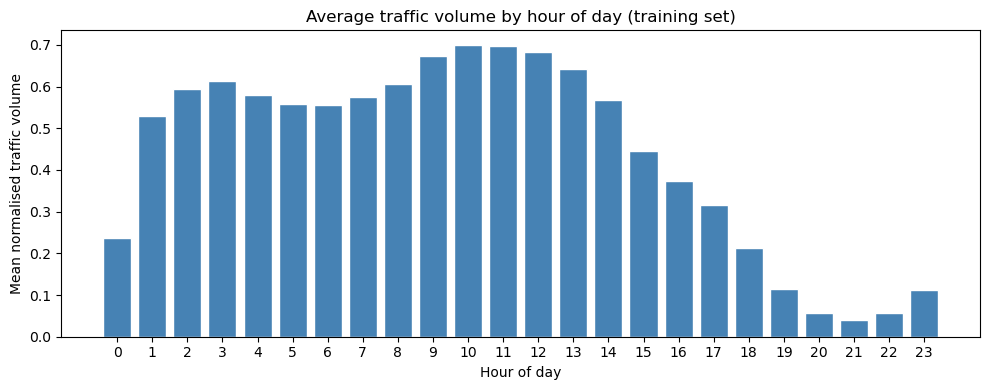

In [5]:
# X_tr shape: (N, 1, 48). Hour-of-day one-hots are columns 17:41.
X_np = X_tr.cpu().numpy().squeeze(1)   # (N, 48)
hour_feats = X_np[:, 17:41]            # (N, 24)

# For each obs, recover which hour it belongs to
hour_idx = hour_feats.argmax(axis=1)   # (N,)

mean_vol_by_hour = [
    Y_tr.cpu().numpy()[hour_idx == h].mean()
    for h in range(24)
]

plt.figure(figsize=(10, 4))
plt.bar(range(24), mean_vol_by_hour, color='steelblue', edgecolor='white')
plt.xlabel('Hour of day')
plt.ylabel('Mean normalised traffic volume')
plt.title('Average traffic volume by hour of day (training set)')
plt.xticks(range(24))
plt.tight_layout()
plt.show()

## 4. Adjacency Matrix (sensor connectivity)

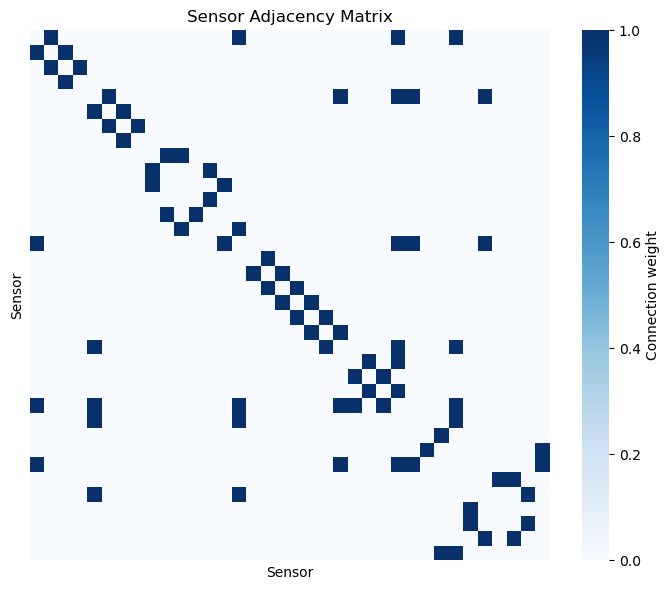

In [7]:
import scipy.sparse as sp

# adj_matrix may be sparse
adj_dense = adj_matrix.toarray() if sp.issparse(adj_matrix) else np.array(adj_matrix)

plt.figure(figsize=(7, 6))
sns.heatmap(adj_dense, cmap='Blues', linewidths=0,
            xticklabels=False, yticklabels=False,
            cbar_kws={'label': 'Connection weight'})
plt.title('Sensor Adjacency Matrix')
plt.xlabel('Sensor')
plt.ylabel('Sensor')
plt.tight_layout()
plt.show()

## 5. Feature Breakdown (one observation)

In [8]:
import pandas as pd

feature_names = (
    [f'traffic_t-{i}' for i in range(10, 0, -1)]
    + [f'weekday_{i}' for i in range(7)]
    + [f'hour_{i}' for i in range(24)]
    + ['dir_N', 'dir_S', 'dir_E', 'dir_W']
    + ['num_lanes']
    + ['road_name_1', 'road_name_2']
)

sample = pd.Series(X_np[0], index=feature_names)
print('Feature values for observation 0:')
print(sample.to_string())

Feature values for observation 0:
traffic_t-10    0.092480
traffic_t-9     0.096684
traffic_t-8     0.070061
traffic_t-7     0.065857
traffic_t-6     0.078468
traffic_t-5     0.071462
traffic_t-4     0.054180
traffic_t-3     0.044372
traffic_t-2     0.054647
traffic_t-1     0.050911
weekday_0       1.000000
weekday_1       0.000000
weekday_2       0.000000
weekday_3       0.000000
weekday_4       0.000000
weekday_5       1.000000
weekday_6       0.000000
hour_0          0.000000
hour_1          0.000000
hour_2          0.000000
hour_3          0.000000
hour_4          0.000000
hour_5          0.000000
hour_6          0.000000
hour_7          0.000000
hour_8          0.000000
hour_9          0.000000
hour_10         0.000000
hour_11         0.000000
hour_12         0.000000
hour_13         0.000000
hour_14         0.000000
hour_15         0.000000
hour_16         0.000000
hour_17         0.000000
hour_18         0.000000
hour_19         0.000000
hour_20         0.000000
hour_21         